In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, itertools, pickle
from IPython.display import clear_output
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')
from numba import njit 

from python import forces, integrators, random_matrix, simulate, densities, plotters, solvers, newton
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix); importlib.reload(newton);
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters); importlib.reload(solvers);

---

In [2]:
@njit
def get_num_crossings(x):
    M, N = x.shape
    num_crossings = 0

    for m in range(M):
        for i in range(N - 1):
            if (x[m, i] >= x[m, i + 1]):
                num_crossings += 1
                break 

    return num_crossings/M

Better: set a maximal number of crossings and find $k$ in $N^{k}$ s.t. that number is hit (within some tolerance).
 

In [3]:
beta = 2.0; pot_int = 2;

def run_single_step(init, N, dt, method, newton_tol):
    # Run one step, return num crossings (probability).
    noise_scale = np.sqrt(2.0*dt/(beta*N))
    
    if (method.lower() == "imla"):
        # If want, track Newton iterations here.
        x_next, _, newton_iters, mean_cg_iters = integrators.imla_newton_step(init, dt, pot_int, noise_scale, newton_tol = newton_tol)

    elif method.lower() == "euler":
        coulomb = forces.coulomb_interaction(init)
        v_prime = forces.evaluate_force(init, pot_int, 1)
        x_next = integrators.euler_step(init, coulomb, v_prime, dt, noise_scale)
    else:
        raise ValueError("Unknown method")
    
    return get_num_crossings(x_next), {"newton": newton_iters, "cg": mean_cg_iters}

# ====================================================================================

def find_max_dt_exponent(init, N, method, target, exp_low, exp_high, tol, newton_tol = 1e-6):
    # Exp being "exponent" k in N^k.
    best_exp = exp_low
    while (exp_high - exp_low) > tol:
        exp_mid = (exp_low + exp_high)/2.0
        dt_mid = N**(exp_mid) 
        
        # Has M trials (so a single step averages over M anyway.)
        crossings, info = run_single_step(init, N, dt_mid, method, newton_tol)
        
        if (crossings <= target):
            # Increase.
            best_exp = exp_mid
            exp_low = exp_mid
        else:
            # Decrease.
            exp_high = exp_mid
            
    return best_exp, info

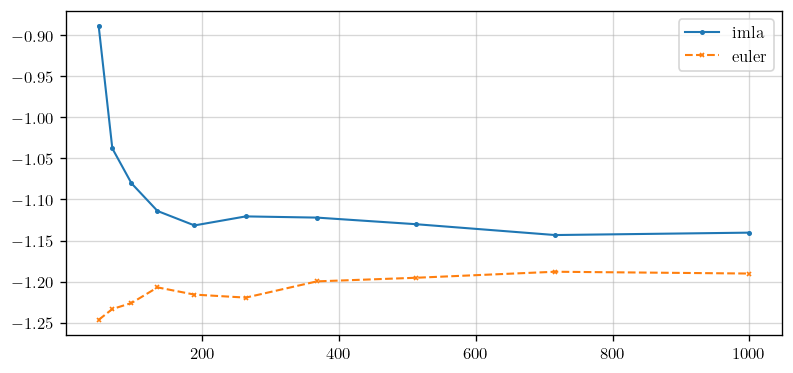

In [ ]:
# Old plot with tol 1e-6 and max_crossings = 0.15
fig, ax = plt.subplots()

ax.plot(N_range, max_exp_imla, marker = 'o', label = "imla")
ax.plot(N_range, max_exp_euler, marker = 'x', linestyle = '--', label = "euler")

ax.legend()
plt.show()

---

Test the results.

---
---
---

How does the Newton tolerance influence?

In [ ]:
tolerances = [1e-6, 1e-12]
results = {}

N_range = np.logspace(np.log10(100), np.log10(1000), 10, dtype = int)
M = 100; beta = 2; pot_int = 2; max_crossings = 0.15

exp_min = -3.0; exp_max = 0.0; # e.g. dt = 10^0 = 1.
search_tol = 1e-3

for tol in tolerances:   
    clear_output(wait = True)

    max_exp_imla = np.zeros(len(N_range), dtype = float)
    mean_newton_iters = np.zeros(len(N_range), dtype = float)
    mean_cg_iters = np.zeros(len(N_range), dtype = float)
    
    for j, N in enumerate(N_range):
        print(f"Tol {tol} on N {N}.")
        init = random_matrix.init_quartic_eigenvalues(M, N, dt = 0.05)
        exponent, info = find_max_dt_exponent(init, N, "imla", max_crossings, 
                        exp_min, exp_max, search_tol, newton_tol = tol)
        
        max_exp_imla[j] = exponent
        mean_newton_iters[j] = info["newton"].mean()
        mean_cg_iters[j] = info["cg"].mean()
        
    results[tol] = {
        "max_exp": max_exp_imla,
        "mean_newton": mean_newton_iters,
        "mean_cg": mean_cg_iters
    }

Tol 1e-12 on N 30.
Tol 1e-12 on N 50.
Tol 1e-12 on N 100.


In [5]:
results

{1e-06: {'max_exp': array([-0.67456055, -0.890625  , -1.1081543 ]),
  'mean_newton': array([4.96, 4.78, 4.55]),
  'mean_cg': array([9.018     , 7.72      , 5.88883333])},
 1e-12: {'max_exp': array([-0.84448242, -0.92944336, -1.06054688]),
  'mean_newton': array([11.36, 10.53,  9.41]),
  'mean_cg': array([3.91081727, 3.97852505, 3.71448968])}}